# GRU workflow tool-sequence experiment

This notebook loads the workflow connection TSV, preprocesses it into tool sequences, and trains a simple GRU model to predict the next tool.

In [1]:
from pathlib import Path
import pandas as pd

def find_project_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "config.yml").exists() or (p / "requirements.txt").exists():
            return p
    return start

root = find_project_root(Path.cwd().resolve())

tsv_path = root / "agents" / "expriments" / "data" / "usegalaxy_workflow_connections_2026-02-11_10-48-58.tsv"
print("TSV exists:", tsv_path.exists(), "->", tsv_path)

df = pd.read_csv(tsv_path, sep="\t")
print(df.shape)
df.head()

TSV exists: True -> /mnt/hdd_1/yohanes/test/galaxy-agent-xp-II/agents/expriments/data/usegalaxy_workflow_connections_2026-02-11_10-48-58.tsv
(48598, 11)


,workflow_id,workflow_name,created_at,source_step_id,source_tool,source_tool_version,source_output_name,target_step_id,target_tool,target_tool_version,target_input_name
0,b65280467af44ffd,16S Microbial analysis with Nanopore data (Final),2026-02-04T18:54:40.389712,0,Input,NaN,output,1,toolshed.g2.bx.psu.edu/repos/devteam/fastqc/fa...,0.74+galaxy1,input_file
1,b65280467af44ffd,16S Microbial analysis with Nanopore data (Final),2026-02-04T18:54:40.389712,0,Input,NaN,output,2,toolshed.g2.bx.psu.edu/repos/iuc/porechop/pore...,0.2.4+galaxy1,input_file
2,b65280467af44ffd,16S Microbial analysis with Nanopore data (Final),2026-02-04T18:54:40.389712,1,toolshed.g2.bx.psu.edu/repos/devteam/fastqc/fa...,0.74+galaxy1,text_file,3,toolshed.g2.bx.psu.edu/repos/iuc/multiqc/multi...,1.33+galaxy0,results_0|software_cond|output_0|input
3,b65280467af44ffd,16S Microbial analysis with Nanopore data (Final),2026-02-04T18:54:40.389712,2,toolshed.g2.bx.psu.edu/repos/iuc/porechop/pore...,0.2.4+galaxy1,outfile,4,toolshed.g2.bx.psu.edu/repos/iuc/fastp/fastp/1...,1.1.0+galaxy0,single_paired|in1
4,b65280467af44ffd,16S Microbial analysis with Nanopore data (Final),2026-02-04T18:54:40.389712,4,toolshed.g2.bx.psu.edu/repos/iuc/fastp/fastp/1...,1.1.0+galaxy0,out1,5,toolshed.g2.bx.psu.edu/repos/devteam/fastqc/fa...,0.74+galaxy1,input_file


In [2]:
import numpy as np

# The new TSV includes a header row, so reuse the DataFrame with headers
raw = df.copy()
raw.head()

,workflow_id,workflow_name,created_at,source_step_id,source_tool,source_tool_version,source_output_name,target_step_id,target_tool,target_tool_version,target_input_name
0,b65280467af44ffd,16S Microbial analysis with Nanopore data (Final),2026-02-04T18:54:40.389712,0,Input,NaN,output,1,toolshed.g2.bx.psu.edu/repos/devteam/fastqc/fa...,0.74+galaxy1,input_file
1,b65280467af44ffd,16S Microbial analysis with Nanopore data (Final),2026-02-04T18:54:40.389712,0,Input,NaN,output,2,toolshed.g2.bx.psu.edu/repos/iuc/porechop/pore...,0.2.4+galaxy1,input_file
2,b65280467af44ffd,16S Microbial analysis with Nanopore data (Final),2026-02-04T18:54:40.389712,1,toolshed.g2.bx.psu.edu/repos/devteam/fastqc/fa...,0.74+galaxy1,text_file,3,toolshed.g2.bx.psu.edu/repos/iuc/multiqc/multi...,1.33+galaxy0,results_0|software_cond|output_0|input
3,b65280467af44ffd,16S Microbial analysis with Nanopore data (Final),2026-02-04T18:54:40.389712,2,toolshed.g2.bx.psu.edu/repos/iuc/porechop/pore...,0.2.4+galaxy1,outfile,4,toolshed.g2.bx.psu.edu/repos/iuc/fastp/fastp/1...,1.1.0+galaxy0,single_paired|in1
4,b65280467af44ffd,16S Microbial analysis with Nanopore data (Final),2026-02-04T18:54:40.389712,4,toolshed.g2.bx.psu.edu/repos/iuc/fastp/fastp/1...,1.1.0+galaxy0,out1,5,toolshed.g2.bx.psu.edu/repos/devteam/fastqc/fa...,0.74+galaxy1,input_file


In [3]:
# Basic data audit to inspect special cases (Input tool, missing versions)

# Show columns and missingness
print("Columns:", list(raw.columns))
print("Missing values per column:\n", raw.isna().sum())

# Frequency of source/target tools
print("Top source_tool values:\n", raw["source_tool"].astype(str).value_counts().head(10))
print("Top target_tool values:\n", raw["target_tool"].astype(str).value_counts().head(10))

# Inspect Input cases
input_cases = raw[(raw["source_tool"].astype(str).str.strip() == "Input") | (raw["target_tool"].astype(str).str.strip() == "Input")]
print("Rows with Input tool:", len(input_cases))

# Check missing versions when Input appears
if not input_cases.empty:
    print("Missing source_tool_version when source_tool=Input:",
          input_cases[input_cases["source_tool"].astype(str).str.strip()=="Input"]["source_tool_version"].isna().mean())
    print("Missing target_tool_version when target_tool=Input:",
          input_cases[input_cases["target_tool"].astype(str).str.strip()=="Input"]["target_tool_version"].isna().mean())

# Sample a few Input rows to inspect
input_cases.head(10)

Columns: ['workflow_id', 'workflow_name', 'created_at', 'source_step_id', 'source_tool', 'source_tool_version', 'source_output_name', 'target_step_id', 'target_tool', 'target_tool_version', 'target_input_name']
Missing values per column:
 workflow_id                0
workflow_name              0
created_at                 0
source_step_id             0
source_tool                0
source_tool_version    16856
source_output_name         0
target_step_id             0
target_tool                0
target_tool_version     4993
target_input_name          0
dtype: int64
Top source_tool values:
 source_tool
Input                                                                               14411
toolshed.g2.bx.psu.edu/repos/iuc/macs2/macs2_callpeak/2.2.9.1+galaxy0                1512
Cut1                                                                                 1188
toolshed.g2.bx.psu.edu/repos/devteam/samtool_filter2/samtool_filter2/1.8+galaxy1     1021
param_value_from_file           

,workflow_id,workflow_name,created_at,source_step_id,source_tool,source_tool_version,source_output_name,target_step_id,target_tool,target_tool_version,target_input_name
0,b65280467af44ffd,16S Microbial analysis with Nanopore data (Final),2026-02-04T18:54:40.389712,0,Input,NaN,output,1,toolshed.g2.bx.psu.edu/repos/devteam/fastqc/fa...,0.74+galaxy1,input_file
1,b65280467af44ffd,16S Microbial analysis with Nanopore data (Final),2026-02-04T18:54:40.389712,0,Input,NaN,output,2,toolshed.g2.bx.psu.edu/repos/iuc/porechop/pore...,0.2.4+galaxy1,input_file
11,0942f2f3386e6b41,dada2 amplicon analysis pipeline - for paired ...,2025-03-06T00:15:10.663602,0,Input,NaN,output,5,__APPLY_RULES__,1.1.0,input
14,0942f2f3386e6b41,dada2 amplicon analysis pipeline - for paired ...,2025-03-06T00:15:10.663602,2,Input,NaN,output,7,toolshed.g2.bx.psu.edu/repos/iuc/dada2_filtera...,1.34.0+galaxy0,seprev_cond|trim|truncLen
15,0942f2f3386e6b41,dada2 amplicon analysis pipeline - for paired ...,2025-03-06T00:15:10.663602,1,Input,NaN,output,7,toolshed.g2.bx.psu.edu/repos/iuc/dada2_filtera...,1.34.0+galaxy0,trim|truncLen
21,0942f2f3386e6b41,dada2 amplicon analysis pipeline - for paired ...,2025-03-06T00:15:10.663602,3,Input,NaN,output,12,toolshed.g2.bx.psu.edu/repos/iuc/dada2_dada/da...,1.34.0+galaxy0,batch_cond|pool
24,0942f2f3386e6b41,dada2 amplicon analysis pipeline - for paired ...,2025-03-06T00:15:10.663602,3,Input,NaN,output,13,toolshed.g2.bx.psu.edu/repos/iuc/dada2_dada/da...,1.34.0+galaxy0,batch_cond|pool
38,0942f2f3386e6b41,dada2 amplicon analysis pipeline - for paired ...,2025-03-06T00:15:10.663602,4,Input,NaN,output,18,toolshed.g2.bx.psu.edu/repos/iuc/dada2_assignt...,1.34.0+galaxy0,reference_cond|refFasta
40,7b48649b0ce3950f,imported: Find exons with the highest number o...,2026-02-06T07:38:24.077832,0,Input,NaN,output,2,toolshed.g2.bx.psu.edu/repos/iuc/bedtools/bedt...,2.31.1+galaxy0,inputA
41,7b48649b0ce3950f,imported: Find exons with the highest number o...,2026-02-06T07:38:24.077832,1,Input,NaN,output,2,toolshed.g2.bx.psu.edu/repos/iuc/bedtools/bedt...,2.31.1+galaxy0,reduce_or_iterate|inputB


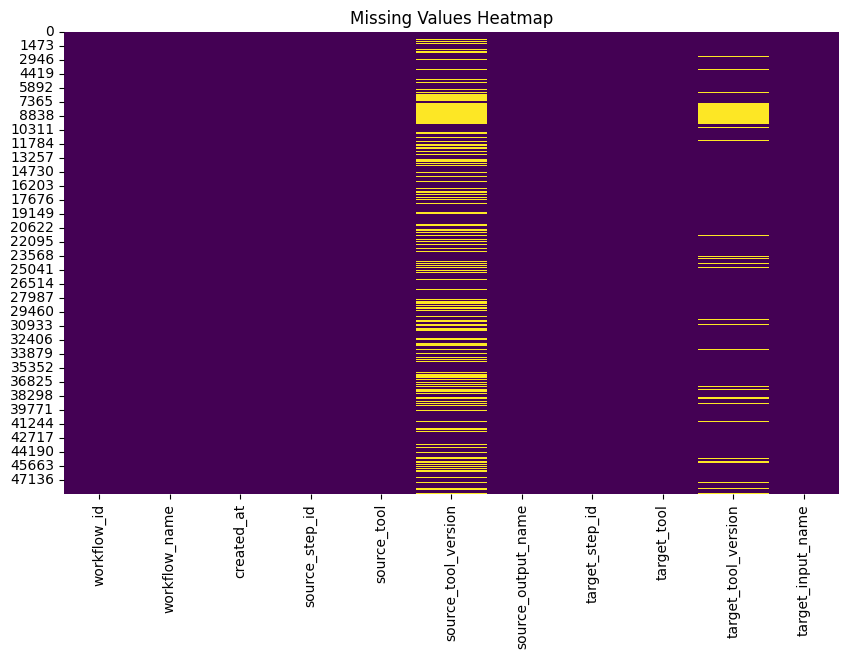

/tmp/ipykernel_876339/1645305237.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


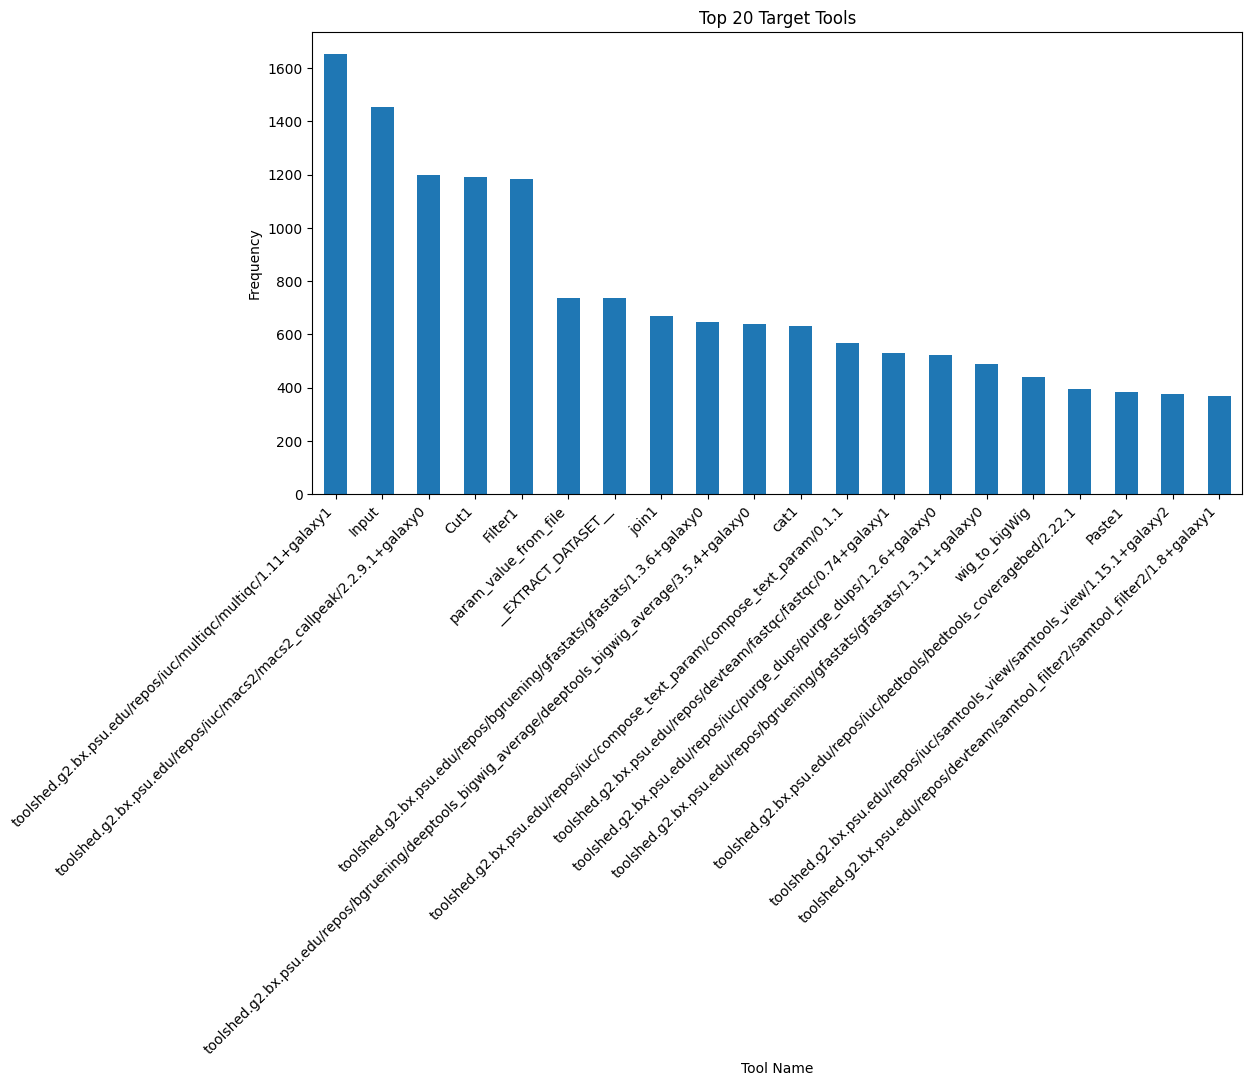

Number of rows where source_tool is 'Input': 14411
Version distribution for 'Input' source tool:
source_tool_version
NaN    14411
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing Missing Values
plt.figure(figsize=(10, 6))
sns.heatmap(raw.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# Visualize Top Tools
top_n = 20
plt.figure(figsize=(12, 6))
raw["target_tool"].astype(str).value_counts().head(top_n).plot(kind="bar")
plt.title(f"Top {top_n} Target Tools")
plt.ylabel("Frequency")
plt.xlabel("Tool Name")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Analyze 'Input' tool rows specifically
input_rows = raw[raw["source_tool"].astype(str).str.strip() == "Input"]
print(f"Number of rows where source_tool is 'Input': {len(input_rows)}")
print("Version distribution for 'Input' source tool:")
print(input_rows["source_tool_version"].value_counts(dropna=False))

In [7]:
# Cleaning Step based on analysis

# "Input" represents the start of a workflow (not a processing tool). 
# Its version is always NaN. We will standardize this to represent the intuition
# that it is a special initial state, distinct from regular tools.

# 1. Standardize "Input" token
# We rename "Input" to "<INPUT_DATA>" to explicitly represent it as an initial step/state in our sequences.
raw.loc[raw["source_tool"].astype(str).str.strip() == "Input", "source_tool"] = "<INPUT_DATA>"
raw.loc[raw["target_tool"].astype(str).str.strip() == "Input", "target_tool"] = "<INPUT_DATA>"

# 2. Handle specific versioning for Input
# Since it's not a tool, we assign "n/a" to indicate it represents the dataset itself.
mask_input_source = raw["source_tool"] == "<INPUT_DATA>"
raw.loc[mask_input_source, "source_tool_version"] = raw.loc[mask_input_source, "source_tool_version"].fillna("n/a")

mask_input_target = raw["target_tool"] == "<INPUT_DATA>"
raw.loc[mask_input_target, "target_tool_version"] = raw.loc[mask_input_target, "target_tool_version"].fillna("n/a")

# 3. Handle other missing versions (real tools with missing meta)
raw["source_tool_version"] = raw["source_tool_version"].fillna("unknown")
raw["target_tool_version"] = raw["target_tool_version"].fillna("unknown")

# Verify cleanup
print("Renamed 'Input' to '<INPUT_DATA>'.")
input_rows_clean = raw[raw["source_tool"] == "<INPUT_DATA>"]
print("Rows with <INPUT_DATA> as source:", len(input_rows_clean))
print("Version distribution for <INPUT_DATA>:", input_rows_clean["source_tool_version"].unique())

Renamed 'Input' to '<INPUT_DATA>'.
Rows with <INPUT_DATA> as source: 14411
Version distribution for <INPUT_DATA>: <StringArray>
['n/a']
Length: 1, dtype: str


In [8]:
# Preprocess data for link prediction (edge existence)
import numpy as np

required = ["workflow_id", "source_step_id", "target_step_id", "source_tool", "target_tool"]
lp = raw[required].copy()

# Normalize tool names and drop placeholder Input (not a real tool)
for col in ["source_tool", "target_tool"]:
    lp[col] = lp[col].astype(str).str.strip()

lp = lp[~((lp["source_tool"] == "<INPUT_DATA>") | (lp["target_tool"] == "<INPUT_DATA>"))]

# Ensure numeric step ids
lp["workflow_id"] = pd.to_numeric(lp["workflow_id"], errors="coerce").astype("Int64")
lp["source_step_id"] = pd.to_numeric(lp["source_step_id"], errors="coerce").astype("Int64")
lp["target_step_id"] = pd.to_numeric(lp["target_step_id"], errors="coerce").astype("Int64")

# Drop invalids and self-loops
lp = lp.dropna(subset=["workflow_id", "source_step_id", "target_step_id"]) 
lp = lp[lp["source_step_id"] != lp["target_step_id"]]

# Edge list (deduplicate)
edges = lp[["source_step_id", "target_step_id"]].drop_duplicates()
print("Total edges:", len(edges))

# Node list
nodes = pd.unique(edges[["source_step_id", "target_step_id"]].values.ravel())
print("Total nodes:", len(nodes))

# Split edges into train/val/test
rng = np.random.default_rng(42)
edges_array = edges.to_numpy()
perm = rng.permutation(len(edges_array))

train_end = int(0.8 * len(edges_array))
val_end = int(0.9 * len(edges_array))

train_edges = edges_array[perm[:train_end]]
val_edges = edges_array[perm[train_end:val_end]]
test_edges = edges_array[perm[val_end:]]

print("Train/Val/Test:", len(train_edges), len(val_edges), len(test_edges))

# Negative sampling (pairs not in edges)
edge_set = set(map(tuple, edges_array))
node_list = nodes.tolist()

def sample_negatives(num_samples):
    negatives = set()
    while len(negatives) < num_samples:
        src = rng.choice(node_list)
        dst = rng.choice(node_list)
        if src == dst:
            continue
        pair = (int(src), int(dst))
        if pair in edge_set:
            continue
        negatives.add(pair)
    return np.array(list(negatives))

train_neg = sample_negatives(len(train_edges))
val_neg = sample_negatives(len(val_edges))
test_neg = sample_negatives(len(test_edges))

print("Negatives:", len(train_neg), len(val_neg), len(test_neg))

Total edges: 8
Total nodes: 7
Train/Val/Test: 6 1 1
Negatives: 6 1 1


In [9]:
from collections import defaultdict, deque

# Build tool sequences per workflow using a simple topological sort

def topo_sequence_for_workflow(df_wf):
    # Map step_id -> tool name (prefer source tool, then target tool)
    step_to_tool = {}
    for _, row in df_wf.iterrows():
        step_to_tool[int(row.source_step_id)] = row.source_tool
        step_to_tool[int(row.target_step_id)] = row.target_tool

    # Build adjacency and indegree
    adj = defaultdict(list)
    indeg = defaultdict(int)
    nodes = set()

    for _, row in df_wf.iterrows():
        s = int(row.source_step_id)
        t = int(row.target_step_id)
        adj[s].append(t)
        indeg[t] += 1
        nodes.add(s)
        nodes.add(t)
        indeg.setdefault(s, 0)

    # Kahn's algorithm with deterministic ordering
    queue = deque(sorted([n for n in nodes if indeg[n] == 0]))
    topo = []
    while queue:
        n = queue.popleft()
        topo.append(n)
        for m in adj.get(n, []):
            indeg[m] -= 1
            if indeg[m] == 0:
                queue.append(m)
        queue = deque(sorted(queue))

    if len(topo) != len(nodes):
        # Cycle or disconnected: fallback to sorted step ids
        topo = sorted(nodes)

    return [step_to_tool.get(step_id, "<UNK>") for step_id in topo]

# Create sequences (sample to keep memory reasonable for the demo)
workflow_ids = raw["workflow_id"].dropna().unique()
print("Total workflows:", len(workflow_ids))

sample_size = 5000  # adjust for speed
sample_ids = set(workflow_ids[:sample_size])

sequences = []
for wf_id, df_wf in raw[raw["workflow_id"].isin(sample_ids)].groupby("workflow_id"):
    seq = topo_sequence_for_workflow(df_wf)
    if len(seq) >= 2:
        sequences.append(seq)

print("Sequences:", len(sequences))
print("Example sequence:", sequences[0][:10])

Total workflows: 2189
Sequences: 2189
Example sequence: ['<INPUT_DATA>', '<INPUT_DATA>', '<INPUT_DATA>', '<INPUT_DATA>', 'fastq_stats', 'toolshed.g2.bx.psu.edu/repos/devteam/bwa_wrappers/bwa_wrapper/1.2.3', 'qual_stats_boxplot', 'sam_bw_filter', 'sam_to_bam', 'picard_ARRG']


Training for 60 epochs...
Epoch 1/60 | train_loss: 4.4566 | val_loss: 3.5661 | top1: 0.460 | top5: 0.651 | lr: 8.0e-04
Epoch 2/60 | train_loss: 3.2846 | val_loss: 3.1079 | top1: 0.543 | top5: 0.724 | lr: 8.0e-04
Epoch 3/60 | train_loss: 2.8790 | val_loss: 2.8952 | top1: 0.572 | top5: 0.764 | lr: 8.0e-04
Epoch 4/60 | train_loss: 2.6543 | val_loss: 2.7583 | top1: 0.598 | top5: 0.798 | lr: 8.0e-04
Epoch 5/60 | train_loss: 2.5030 | val_loss: 2.6704 | top1: 0.622 | top5: 0.810 | lr: 8.0e-04
Epoch 6/60 | train_loss: 2.3867 | val_loss: 2.6245 | top1: 0.635 | top5: 0.817 | lr: 8.0e-04
Epoch 7/60 | train_loss: 2.2976 | val_loss: 2.5733 | top1: 0.645 | top5: 0.826 | lr: 8.0e-04
Epoch 8/60 | train_loss: 2.2256 | val_loss: 2.5410 | top1: 0.653 | top5: 0.831 | lr: 8.0e-04
Epoch 9/60 | train_loss: 2.1639 | val_loss: 2.5005 | top1: 0.663 | top5: 0.837 | lr: 8.0e-04
Epoch 10/60 | train_loss: 2.1109 | val_loss: 2.4872 | top1: 0.668 | top5: 0.839 | lr: 8.0e-04
Epoch 11/60 | train_loss: 2.0632 | val_loss

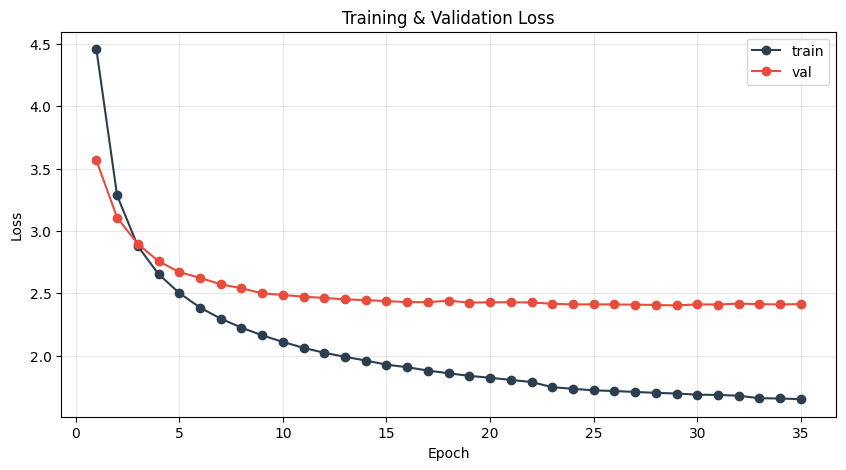


Model saved to: /mnt/hdd_1/yohanes/test/galaxy-agent-xp-II/agents/expriments/models/gru_model_20260213_030205.pth
Reports saved to: /mnt/hdd_1/yohanes/test/galaxy-agent-xp-II/agents/expriments/reports


In [12]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import json
import time
import math
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ---- Data prep improvements ----
context_len = 10
min_tool_count = 5  # map rare tools to <UNK> to reduce vocab noise

# Count tools across all sequences
tool_counts = {}
for seq in sequences:
    for t in seq:
        tool_counts[t] = tool_counts.get(t, 0) + 1

# Replace rare tools with <UNK>
sequences_filtered = [
    [t if tool_counts.get(t, 0) >= min_tool_count else "<UNK>" for t in seq]
    for seq in sequences
    if len(seq) >= 2
 ]

# Train/val split by workflow sequence (reduces leakage)
rng = np.random.default_rng(42)
idx = rng.permutation(len(sequences_filtered))
val_ratio = 0.1
val_size = max(1, int(len(idx) * val_ratio))
val_idx = set(idx[:val_size])
train_sequences = [sequences_filtered[i] for i in idx if i not in val_idx]
val_sequences = [sequences_filtered[i] for i in idx if i in val_idx]

# Build vocab from train set only
special_tokens = ["<PAD>", "<UNK>"]
all_tools = sorted({tool for seq in train_sequences for tool in seq})
itos = special_tokens + [t for t in all_tools if t not in special_tokens]
stoi = {tok: i for i, tok in enumerate(itos)}

pad_idx = stoi["<PAD>"]
unk_idx = stoi["<UNK>"]

def build_pairs(seq_list):
    X, y = [], []
    for seq in seq_list:
        idxs = [stoi.get(t, unk_idx) for t in seq]
        for i in range(1, len(idxs)):
            start = max(0, i - context_len)
            context = idxs[start:i]
            if len(context) < context_len:
                context = [pad_idx] * (context_len - len(context)) + context
            X.append(context)
            y.append(idxs[i])
    return X, y

# Build training/validation pairs
X_train, y_train = build_pairs(train_sequences)
X_val, y_val = build_pairs(val_sequences)

# Optional cap for speed
max_samples = 400000
if len(X_train) > max_samples:
    X_train = X_train[:max_samples]
    y_train = y_train[:max_samples]

X_train = torch.tensor(X_train, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

class ToolSeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = ToolSeqDataset(X_train, y_train)
val_ds = ToolSeqDataset(X_val, y_val)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

# ---- Model ----
class GRUPredictor(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(emb_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.gru(emb)
        last = out[:, -1, :]
        return self.fc(last)

model = GRUPredictor(len(itos))
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=8e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    correct_top1 = 0
    correct_top5 = 0
    total = 0
    with torch.no_grad():
        for batch_X, batch_y in loader:
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            total_loss += loss.item()
            total += batch_y.size(0)
            top1 = logits.argmax(dim=1)
            correct_top1 += (top1 == batch_y).sum().item()
            top5 = logits.topk(k=min(5, logits.size(1)), dim=1).indices
            correct_top5 += (top5 == batch_y.unsqueeze(1)).any(dim=1).sum().item()
    avg_loss = total_loss / max(1, len(loader))
    return avg_loss, correct_top1 / total, correct_top5 / total

# ---- Training with early stopping and per-epoch JSON report ----
num_epochs = 60
patience = 6
best_val = math.inf
best_state = None
no_improve = 0
loss_history = []
val_history = []
epoch_reports = []

timestamp = time.strftime("%Y%m%d_%H%M%S")
report_dir = root / "agents" / "expriments" / "reports"
report_dir.mkdir(parents=True, exist_ok=True)
model_dir = root / "agents" / "expriments" / "models"
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / f"gru_model_{timestamp}.pth"
vocab_path = model_dir / f"vocab_{timestamp}.json"
training_chart_path = report_dir / f"training_loss_{timestamp}.png"
training_text_path = report_dir / f"training_summary_{timestamp}.txt"
epoch_report_path = report_dir / f"epoch_metrics_{timestamp}.json"

print(f"Training for {num_epochs} epochs...")
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    start = time.time()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / max(1, len(train_loader))
    val_loss, val_top1, val_top5 = evaluate(model, val_loader)
    scheduler.step(val_loss)
    loss_history.append(avg_loss)
    val_history.append(val_loss)

    lr = optimizer.param_groups[0]["lr"]
    epoch_time = time.time() - start
    report = {
        "epoch": epoch + 1,
        "train_loss": avg_loss,
        "val_loss": val_loss,
        "val_top1": val_top1,
        "val_top5": val_top5,
        "lr": lr,
        "seconds": epoch_time,
        "vocab_size": len(itos),
        "context_len": context_len,
        "min_tool_count": min_tool_count,
    }
    epoch_reports.append(report)
    with open(epoch_report_path, "w") as f:
        json.dump(epoch_reports, f, indent=2)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss: {avg_loss:.4f} | val_loss: {val_loss:.4f} | "
        f"top1: {val_top1:.3f} | top5: {val_top5:.3f} | lr: {lr:.1e}"
    )

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print("Early stopping triggered.")
            break

# Restore best model and save
if best_state is not None:
    model.load_state_dict(best_state)
torch.save(model.state_dict(), model_path)
with open(vocab_path, "w") as f:
    json.dump({"stoi": stoi, "itos": itos}, f, indent=2)

# Plot and save loss chart
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', linestyle='-', color='#2c3e50', label="train")
plt.plot(range(1, len(val_history) + 1), val_history, marker='o', linestyle='-', color='#e74c3c', label="val")
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(training_chart_path)
plt.show()

# Save text report
with open(training_text_path, "w") as f:
    f.write(f"Training Session Report - {timestamp}\n")
    f.write("=====================================\n\n")
    f.write(f"Train Sequences: {len(train_sequences)}\n")
    f.write(f"Val Sequences: {len(val_sequences)}\n")
    f.write(f"Train Samples: {len(train_ds)}\n")
    f.write(f"Val Samples: {len(val_ds)}\n")
    f.write(f"Vocabulary Size: {len(itos)}\n")
    f.write(f"Context Length: {context_len}\n")
    f.write(f"Min Tool Count: {min_tool_count}\n")
    f.write(f"Epochs Trained: {len(loss_history)}\n")
    f.write(f"Best Val Loss: {best_val:.4f}\n\n")
    f.write("Model Paths:\n")
    f.write(f"- Model: {model_path}\n")
    f.write(f"- Vocab: {vocab_path}\n")
    f.write(f"- Epoch metrics JSON: {epoch_report_path}\n")

print(f"\nModel saved to: {model_path}")
print(f"Reports saved to: {report_dir}")

In [3]:
from pathlib import Path
import json
import torch
from torch import nn

def find_project_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "config.yml").exists() or (p / "requirements.txt").exists():
            return p
    return start

root = find_project_root(Path.cwd().resolve())
model_dir = root / "agents" / "expriments" / "models"
report_dir = root / "agents" / "expriments" / "reports"

# Load latest vocab + model
vocab_files = sorted(model_dir.glob("vocab_*.json"), key=lambda p: p.stat().st_mtime)
model_files = sorted(model_dir.glob("gru_model_*.pth"), key=lambda p: p.stat().st_mtime)

if not vocab_files or not model_files:
    raise FileNotFoundError("No saved model/vocab found in models/. Run training once to create them.")

vocab_path = vocab_files[-1]
model_path = model_files[-1]
print("Loading vocab:", vocab_path)
print("Loading model:", model_path)

with open(vocab_path, "r") as f:
    vocab = json.load(f)
stoi = vocab["stoi"]
itos = vocab["itos"]

# Try to load context_len from latest epoch report, fallback to 10
epoch_reports = sorted(report_dir.glob("epoch_metrics_*.json"), key=lambda p: p.stat().st_mtime)
context_len = 10
if epoch_reports:
    with open(epoch_reports[-1], "r") as f:
        metrics = json.load(f)
        if metrics:
            context_len = metrics[-1].get("context_len", context_len)

pad_idx = stoi.get("<PAD>", 0)
unk_idx = stoi.get("<UNK>", 1)

class GRUPredictor(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(emb_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.gru(emb)
        last = out[:, -1, :]
        return self.fc(last)

model = GRUPredictor(len(itos))
state = torch.load(model_path, map_location="cpu")
model.load_state_dict(state)
model.eval()

def predict_next_tools(context_tools, top_k=5, temperature=1.0):
    ctx = [stoi.get(t, unk_idx) for t in context_tools][-context_len:]
    if len(ctx) < context_len:
        ctx = [pad_idx] * (context_len - len(ctx)) + ctx
    x = torch.tensor([ctx], dtype=torch.long)
    with torch.no_grad():
        logits = model(x)[0] / max(1e-6, temperature)
        probs = torch.softmax(logits, dim=0)
        topk = torch.topk(probs, k=top_k)
    return [(itos[i], float(p)) for i, p in zip(topk.indices.tolist(), topk.values.tolist())]

# Example prediction
context = ["<INPUT_DATA>", "Filter1", "Group_by1"]
print("Context:", context)
print("Predicted next tools:")
for tool, score in predict_next_tools(context, top_k=10, temperature=0.8):
    print(f"  {tool}: {score:.3f}")

Loading vocab: /mnt/hdd_1/yohanes/test/galaxy-agent-xp-II/agents/expriments/models/vocab_20260213_030205.json
Loading model: /mnt/hdd_1/yohanes/test/galaxy-agent-xp-II/agents/expriments/models/gru_model_20260213_030205.pth
Context: ['<INPUT_DATA>', 'Filter1', 'Group_by1']
Predicted next tools:
  toolshed.g2.bx.psu.edu/repos/devteam/intersect/gops_intersect_1/1.0.0: 0.481
  <UNK>: 0.198
  Filter1: 0.096
  Add_a_column1: 0.090
  sort1: 0.036
  addValue: 0.010
  Grep1: 0.006
  toolshed.g2.bx.psu.edu/repos/devteam/fastqc/fastqc/0.72: 0.005
  Count1: 0.005
  toolshed.g2.bx.psu.edu/repos/miller-lab/genome_diversity/gd_specify/1.1.0: 0.003
